<a href="https://colab.research.google.com/github/Shahul187/f1-eda-2021/blob/main/Chapter_1_Championship_Points.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install fastf1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.3 MB/s eta 0:00:00


In [3]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import os

# Create cache folder if it doesn't exist, then enable it
os.makedirs('/tmp/fastf1_cache', exist_ok=True)
fastf1.Cache.enable_cache('/tmp/fastf1_cache')

In [4]:

points_map = {1:25, 2:18, 3:15, 4:12, 5:10, 6:8, 7:6, 8:4, 9:2, 10:1}

cumulative = {'VER': [], 'HAM': []}
race_names = []

for round_num in range(1, 23):

    try:
        session = fastf1.get_session(2021, round_num, 'R')
        session.load(telemetry=False, weather=False, messages=False)
        results = session.results
        race_name = session.event['EventName'].replace('Grand Prix', 'GP')
    except Exception as e:
        print(f"Round {round_num} failed to load: {e}")
        results = None
        race_name = f"Round {round_num}"


    race_names.append(race_name)


    for drv in ['VER', 'HAM']:
        prev = cumulative[drv][-1] if cumulative[drv] else 0

        if results is not None:
            row = results[results['Abbreviation'] == drv]
            pos = int(row['Position'].values[0]) if not row.empty else 20
            pts = points_map.get(pos, 0)

            try:
                if not row.empty and row['FastestLap'].values[0]:
                    pts += 1
            except:
                pass  # FastestLap column missing — just skip it
        else:
            pts = 0

        cumulative[drv].append(prev + pts)

print(f"Races loaded: {len(race_names)}")

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
DEBUG:fastf1.api:Falling back to livetiming mirror (https://livetiming-mirror.fastf1.dev)
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
DEBUG:fastf1.api:Falling back to livetiming mirror (https://livetiming-mirror.fastf1.dev)
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req

Races loaded: 22


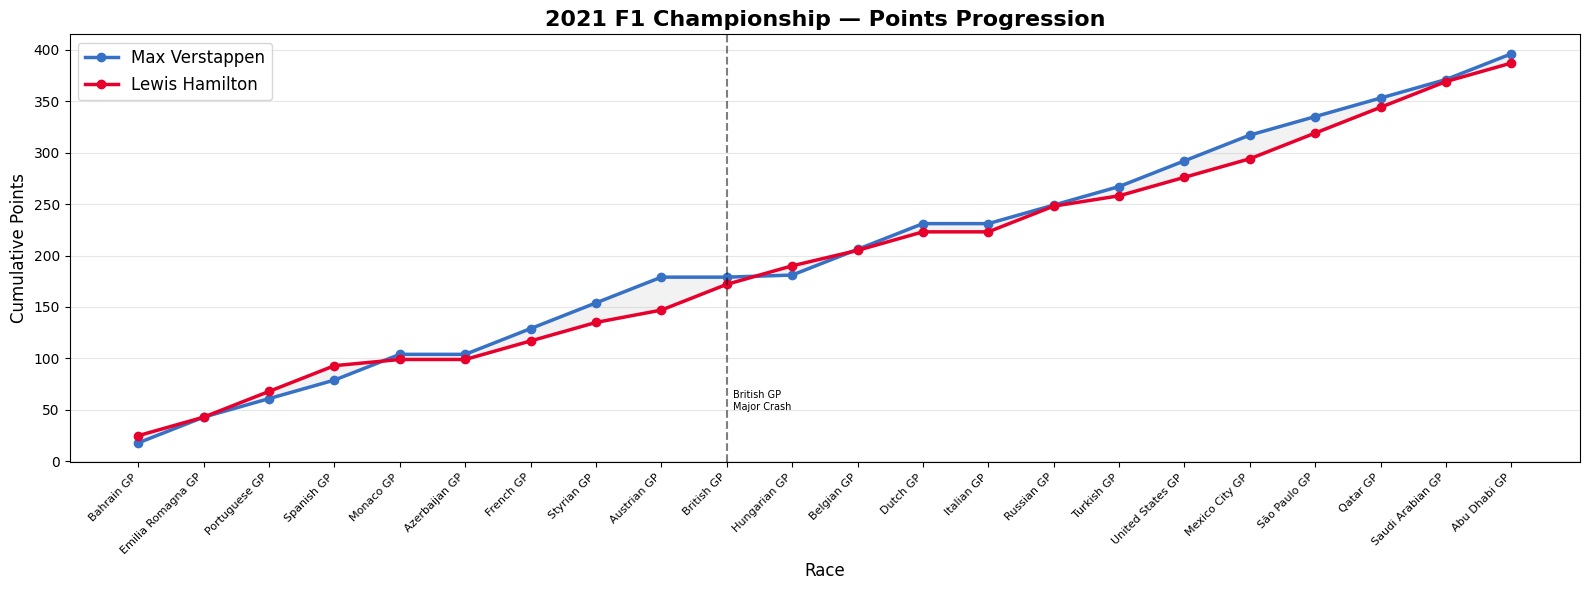

In [7]:
plt.figure(figsize=(16, 6))

plt.plot(race_names, cumulative['VER'], marker='o', color='#3671C6', linewidth=2.5, label='Max Verstappen')
plt.plot(race_names, cumulative['HAM'], marker='o', color='#E8002D', linewidth=2.5, label='Lewis Hamilton')

plt.fill_between(race_names, cumulative['VER'], cumulative['HAM'], alpha=0.1, color='gray')

plt.title('2021 F1 Championship — Points Progression', fontsize=16, fontweight='bold')
plt.xlabel('Race', fontsize=12)
plt.ylabel('Cumulative Points', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.legend(fontsize=12)
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)

british_idx = race_names.index('British GP')
plt.axvline(x=british_idx, color='black', linestyle='--', alpha=0.5)
plt.text(british_idx + 0.1, 50, 'British GP\nMajor Crash', fontsize=7, color='black')
plt.show()

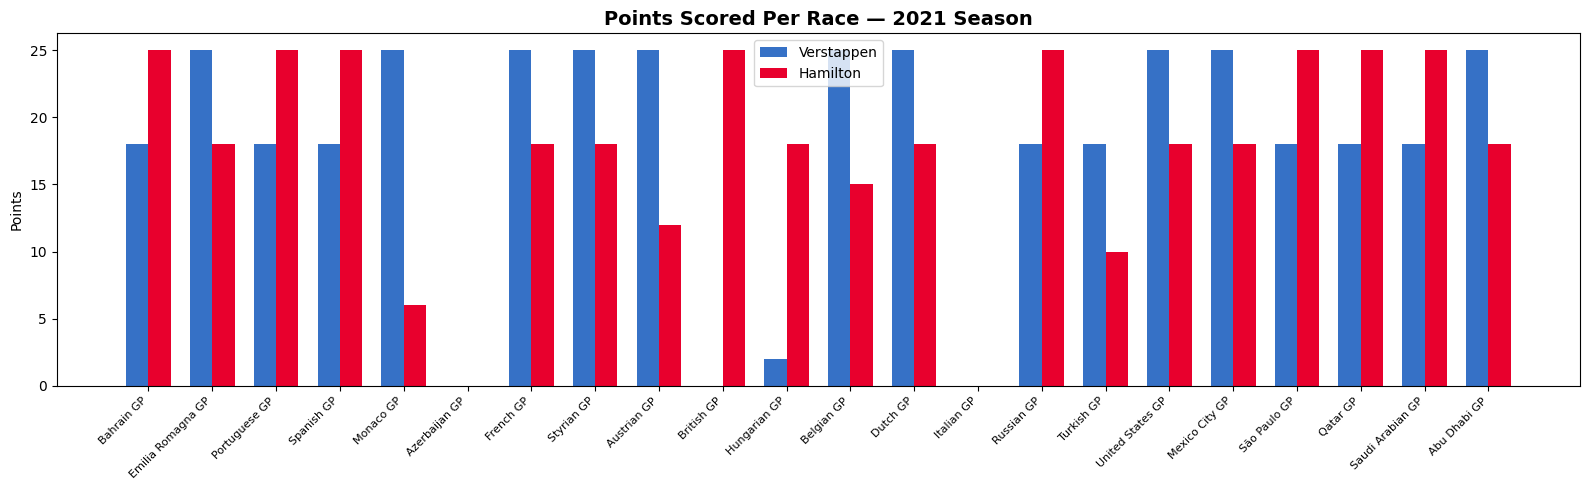

In [8]:
ver_per_race = [cumulative['VER'][0]] + [cumulative['VER'][i] - cumulative['VER'][i-1] for i in range(1, len(cumulative['VER']))]
ham_per_race = [cumulative['HAM'][0]] + [cumulative['HAM'][i] - cumulative['HAM'][i-1] for i in range(1, len(cumulative['HAM']))]

x = range(len(race_names))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar([i - width/2 for i in x], ver_per_race, width, label='Verstappen', color='#3671C6')
ax.bar([i + width/2 for i in x], ham_per_race, width, label='Hamilton', color='#E8002D')

ax.set_xticks(list(x))
ax.set_xticklabels(race_names, rotation=45, ha='right', fontsize=8)
ax.set_title('Points Scored Per Race — 2021 Season', fontsize=14, fontweight='bold')
ax.set_ylabel('Points')
ax.legend()
plt.tight_layout()
plt.show()

## Chapter 1 — Championship Points Progression

The 2021 F1 season was one of the closest title battles in history. It had the answer to the big question, Verstappen's 1st or Hamilton's 8th?
Verstappen led for most of the season, but Hamilton consistently closed
the gap after key incidents, such as the British GP, where a major crash marked a turning point for Hamilton to claw back significant points.

Final standings:
- Max Verstappen: 395.5 pts
- Lewis Hamilton: 387.5 pts

With a margin of just 8 points after 22 races, Verstappen was crowned his 1st F1 World Championship.